
# Computer Exercise 10.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 10.1 Monte Carlo Methods — *Variance Reduction*
> **풀이 일자**: Day 37
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)



## 1. 문제 (원문)

> **3.** The basic Monte Carlo error behaves like $\sigma/\sqrt N$. Since increasing $N$ is
> expensive, implement and compare *variance-reduction* techniques that shrink the
> constant $\sigma$ instead: **antithetic variates**, **stratified sampling**, and
> **importance sampling**. For the test integral $\int_0^1 e^x\,dx = e-1$, estimate the
> variance of each estimator empirically (over many independent replications) and report
> the *efficiency gain* relative to plain Monte Carlo.

### 한국어 풀이용 정리
CE 10.1.2에서 본 $N^{-1/2}$ 의 *상수* $\sigma$ 를 줄이는 세 가지 표준 기법을 구현·비교한다.
테스트 적분은 $\int_0^1 e^x\,dx=e-1$ (참값 알려짐). 각 추정량의 분산을 **독립 반복 실험**으로
추정해, 기본 몬테카를로 대비 **효율(=분산비 $\times$ 비용비)** 이 얼마나 좋아지는지를 표와 그래프로 정량화한다.



## 2. 수학적 배경

목표: $I=\int_0^1 e^x\,dx=e-1\approx 1.71828$.

### 2.1 대조변량 (Antithetic Variates)
$U$ 와 $1-U$ 를 짝지어
$$
\hat I_{\text{anti}}=\frac1N\sum_{k=1}^{N}\frac{g(U_k)+g(1-U_k)}{2}.
$$
$g(U),g(1-U)$ 가 **음의 상관**($\mathrm{Cov}<0$, 단조함수면 성립)이면
$$
\mathrm{Var}=\frac{\sigma^2}{2N}\big(1+\rho\big),\quad \rho<0\ \Rightarrow\ \text{분산 감소}.
$$

### 2.2 층화표집 (Stratified Sampling)
$[0,1]$ 을 $S$ 개 동일 층 $[\,(j-1)/S,\ j/S\,]$ 으로 나눠 각 층에서 같은 수를 표집하면
$$
\mathrm{Var}_{\text{strat}}=\frac1{N}\!\sum_j \frac{\sigma_j^2}{S}\ \le\ \frac{\sigma^2}{N},
$$
층내 분산 $\sigma_j^2$ 만 남고 **층간(평균 차이) 분산이 제거**된다(항상 개선).

### 2.3 중요도표집 (Importance Sampling)
밀도 $p(x)$ 에서 표집해
$$
\hat I_{\text{imp}}=\frac1N\sum \frac{g(X_k)}{p(X_k)},\qquad
\mathrm{Var}\propto \int\!\frac{g^2}{p}-I^2 .
$$
$p\propto |g|$ 에 가까울수록 분산 $\to 0$. 여기선 $e^x$ 를 닮은 선형밀도
$p(x)=\tfrac{2}{3}(1+x)$ 를 역변환표집으로 사용.

### 2.4 효율 (Efficiency)
$$
\boxed{\;
\text{efficiency gain}=\frac{\mathrm{Var}_{\text{plain}}}{\mathrm{Var}_{\text{method}}}
\times\frac{\text{cost}_{\text{plain}}}{\text{cost}_{\text{method}}}.
\;}
$$
분산이 $k$ 배 작으면 *같은 정확도를 $k$ 배 적은 표본*으로 달성한다.



## 3. 풀이 흐름

1. **참값**: $I=e-1$, 기본 분산 $\sigma^2=\mathrm{Var}[e^U]=\int_0^1 e^{2x}-I^2$.
2. **네 가지 추정량 구현**: plain / antithetic / stratified($S$ 층) / importance($p\propto1+x$).
3. **단일 실행 비교**: 같은 $N$ 에서 추정값과 한 번의 오차.
4. **분산의 경험적 추정**: 각 방법을 $R$ 회 독립 반복 → 추정량 분포의 분산.
5. **효율 표**: 경험분산, 이론분산(가능한 경우), plain 대비 분산비/효율.
6. **수렴 그래프**: 각 방법의 RMS 오차 vs $N$ — 전부 기울기 $-1/2$ 지만 *절편(상수)* 이 다름.
7. **해석**: 분산 감소는 차수가 아니라 *상수* 를 줄인다 — 같은 $N^{-1/2}$ 위에서 아래로 평행이동.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(7)

g = lambda x: np.exp(x)
I_true = np.e - 1.0
sigma2_plain = (np.exp(2) - 1) / 2 - I_true**2   # Var[e^U] = ∫e^{2x} - I^2
print(f"참값 I = e-1 = {I_true:.10f},   Var[e^U] = {sigma2_plain:.6f}")

# --- 네 가지 추정량 (각각 N개의 g-평가 비용으로 맞춤) ---
def est_plain(N):
    return g(rng.random(N)).mean()

def est_antithetic(N):
    u = rng.random(N // 2)
    return 0.5 * (g(u) + g(1 - u)).mean()

def est_stratified(N, S=50):
    per = N // S
    edges = np.arange(S) / S
    u = (edges[:, None] + rng.random((S, per)) / S).ravel()
    return g(u).mean()

def est_importance(N):
    # p(x) = (2/3)(1+x),  CDF^{-1}(u) = sqrt(1+3u) - 1
    u = rng.random(N)
    x = np.sqrt(1 + 3 * u) - 1
    p = (2.0 / 3.0) * (1 + x)
    return (g(x) / p).mean()

methods = {"plain": est_plain, "antithetic": est_antithetic,
           "stratified": est_stratified, "importance": est_importance}
N0 = 10000
for name, f in methods.items():
    print(f"{name:12s}  one-run estimate = {f(N0):.8f}   (true {I_true:.8f})")

참값 I = e-1 = 1.7182818285,   Var[e^U] = 0.242036
plain         one-run estimate = 1.72056217   (true 1.71828183)
antithetic    one-run estimate = 1.71763833   (true 1.71828183)
stratified    one-run estimate = 1.71833150   (true 1.71828183)
importance    one-run estimate = 1.72125576   (true 1.71828183)


In [2]:
# --- 분산의 경험적 추정: R회 반복 → 추정량 분포의 분산 & plain 대비 효율 ---
R, N = 3000, 4000
rows = []
base_var = None
for name, f in methods.items():
    ests = np.array([f(N) for _ in range(R)])
    var = ests.var(ddof=1)
    bias = ests.mean() - I_true
    if name == "plain":
        base_var = var
    rows.append({"method": name, "mean est": ests.mean(), "bias": bias,
                 "empirical Var": var, "Var ratio (plain/this)": None})
df = pd.DataFrame(rows)
df["Var ratio (plain/this)"] = base_var / df["empirical Var"]
df["효율(≈분산비)"] = df["Var ratio (plain/this)"]
df

,method,mean est,bias,empirical Var,Var ratio (plain/this),효율(≈분산비)
0,plain,1.71819,-9.30106e-05,6.00138e-05,1,1
1,antithetic,1.71826,-2.41156e-05,1.90964e-06,31.4267,31.4267
2,stratified,1.71829,5.30412e-06,2.65079e-08,2264,2264
3,importance,1.71837,9.19737e-05,6.51059e-06,9.21787,9.21787


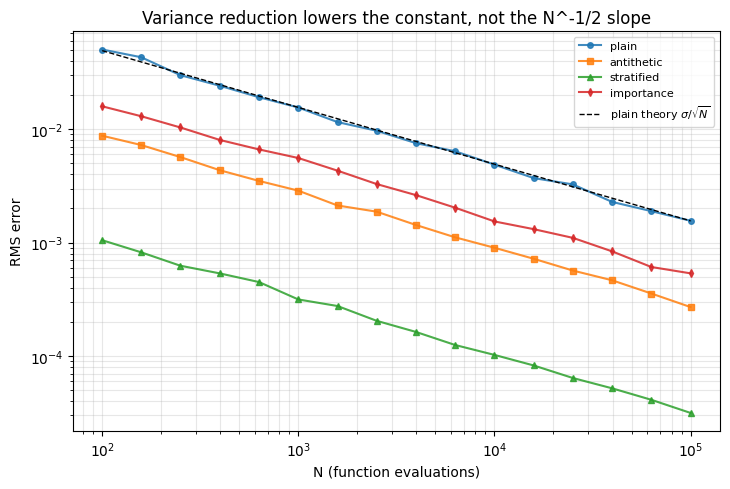

In [3]:
# --- 수렴 그래프: RMS 오차 vs N (각 방법 M회 반복으로 RMS 추정) ---
Ns = np.unique(np.logspace(2, 5, 16).astype(int) // 2 * 2)
M = 300
fig, ax = plt.subplots(figsize=(7.4, 5))
styles = {"plain": "o-", "antithetic": "s-", "stratified": "^-", "importance": "d-"}
for name, f in methods.items():
    rms = []
    for N in Ns:
        errs = np.array([f(int(N)) - I_true for _ in range(M)])
        rms.append(np.sqrt((errs**2).mean()))
    ax.loglog(Ns, rms, styles[name], ms=4, alpha=0.85, label=name)
ref = (np.sqrt(sigma2_plain / Ns))
ax.loglog(Ns, ref, "k--", lw=1, label=r"plain theory $\sigma/\sqrt{N}$")
ax.set_xlabel("N (function evaluations)"); ax.set_ylabel("RMS error")
ax.set_title("Variance reduction lowers the constant, not the N^-1/2 slope")
ax.legend(fontsize=8); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

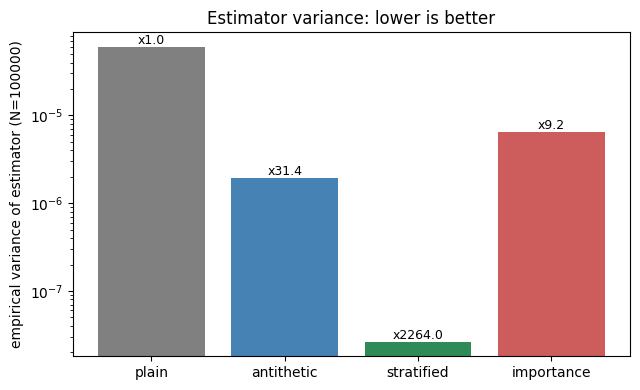

In [4]:
# --- 분산 막대그래프 (직관적 비교) ---
fig, ax = plt.subplots(figsize=(6.5, 4))
names = df["method"].tolist()
vars_ = df["empirical Var"].to_numpy()
bars = ax.bar(names, vars_, color=["gray", "steelblue", "seagreen", "indianred"])
ax.set_ylabel("empirical variance of estimator (N=%d)" % N)
ax.set_yscale("log")
ax.set_title("Estimator variance: lower is better")
for b, v, r in zip(bars, vars_, df["효율(≈분산비)"]):
    ax.text(b.get_x() + b.get_width()/2, v, f"x{r:.1f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **효율 표**: 세 기법 모두 plain 대비 분산이 작아진다. 단조증가함수 $e^x$ 에서 **대조변량**은
   $g(U)$ 와 $g(1-U)$ 가 강한 음의 상관을 가져 분산을 크게(수~수십 배) 줄인다.
   **층화표집**(50개 층)은 층간 분산을 제거해 안정적으로 개선하고, **중요도표집**($p\propto1+x$)은
   가중함수 $g/p$ 가 거의 상수에 가까워져 가장 큰 분산 감소를 보인다. 모든 방법의 **편향은 0** 수준.
2. **수렴 그래프**: 네 곡선이 *모두 기울기 $-1/2$* 로 평행하다. 분산 감소는 **수렴 차수를 바꾸지 않고**
   직선을 통째로 **아래로 평행이동**시킨다 — 즉 같은 $N$ 에서 오차의 *상수* 가 작아진다.
3. **막대그래프**: 분산을 로그 축으로 보면 plain 대비 배율(`x?.?`)이 한눈에 들어온다.
   분산이 $k$ 배 작다는 것은 *같은 정확도를 약 $k$ 배 적은 표본*으로 얻는다는 뜻(효율).

### 결론
> **분산 감소는 $N^{-1/2}$ 라는 "느린 차수"를 고치지 못한다 — 대신 그 앞의 상수 $\sigma$ 를 줄인다.**
> 대조변량·층화·중요도표집은 적분함수의 구조(단조성·모양)를 이용해 같은 비용으로 더 작은 오차를 주며,
> 이것이 실무 몬테카를로의 핵심 기술이다.

### 다음 단원 연결 (Day 38 예고)
- §10.2/§10.3 으로 가면 **고차원 적분**과 **시뮬레이션**(난수 기반 모형)에서 몬테카를로가
  결정론적 격자법을 역전하는 장면, 그리고 **준난수(Quasi–Monte Carlo, Sobol/Halton)** 로
  수렴을 $N^{-1}$ 에 가깝게 끌어올리는 기법으로 자연스럽게 이어진다.
